<div style='background: linear-gradient(135deg, #1a237e, #283593); padding: 40px 30px; border-radius: 12px; color: white; margin-bottom: 10px;'>
<h1 style='font-size: 2.4em; margin: 0 0 10px 0;'>🎓 Student Performance — Data Analysis</h1>
<p style='font-size: 1.1em; opacity: 0.85; margin: 0 0 6px 0;'>BrainerX Workshop — Introduction to Data Manipulation with Python</p>
<p style='font-size: 0.95em; opacity: 0.65; margin: 0;'>Dataset: StudentsPerformance.csv &nbsp;|&nbsp; Tool: Python + Pandas 🐼</p>
</div>

## 👋 Welcome!

In this notebook, I'm going to walk you through how I analyse a real student performance dataset — step by step.

We'll cover everything from loading the file to making charts. Don't worry if you're new to Python — I'll explain every line as we go.

By the end, you will know how to:

| # | What you'll learn |
|---|---|
| 1 | Load a CSV dataset into Python |
| 2 | Explore and understand the data |
| 3 | Clean it up and create new columns |
| 4 | Filter, sort and group the data |
| 5 | Make charts to see patterns |

> 💡 **Tip:** Run each cell one by one using `Shift + Enter`. Don't skip ahead!

---
## 📦 Step 1 — Import Our Libraries

The very first thing I always do is import the libraries I need.

Think of a **library** like a toolbox — it gives us extra powers that Python doesn't have by default.

Here's what each one does:

- 🐼 **`pandas`** → reads and manipulates data (our main tool today)
- 🔢 **`numpy`** → handles numbers and math
- 📊 **`matplotlib`** → draws basic charts
- 🎨 **`seaborn`** → draws beautiful charts (built on top of matplotlib)

In [1]:
import pandas as pd               # I always alias it as 'pd'
import numpy as np                # alias 'np'
import matplotlib.pyplot as plt   # alias 'plt'
import seaborn as sns             # alias 'sns'


print('✅ All libraries imported!')

✅ All libraries imported!


---
## 📥 Step 2 — Load the Dataset

Now let's load our data. I use `pd.read_csv()` to read the file and store it in a variable I call **`df`** (short for DataFrame).

A **DataFrame** is basically a table — like Excel but inside Python.

```
df = pd.read_csv('path/to/your/file.csv')
```

> ⚠️ **Important:** Change the path below to match where *your* file is saved.

In [2]:
df = pd.read_csv('C:\\Users\\j\\Desktop\\BrainerX\\notebooks\\datasets\\StudentsPerformance.csv')

# Let's immediately confirm it loaded correctly
print(f'✅ Data loaded!')
print(f'   → {df.shape[0]} rows  (students)')
print(f'   → {df.shape[1]} columns (variables)')

✅ Data loaded!
   → 1000 rows  (students)
   → 8 columns (variables)


---
## 🔍 Step 3 — First Look at the Data

Before doing anything, I always look at the data first. These are my go-to commands right after loading any dataset.

In [3]:
# Show the first 5 rows — this gives us a feel for what the data looks like
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# Show the last 5 rows — just to make sure the data didn't cut off
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
# List all column names — I always do this to know what variables I'm working with
print('📌 Columns in our dataset:')
for col in df.columns:
    print(f'   - {col}')

📌 Columns in our dataset:
   - gender
   - race/ethnicity
   - parental level of education
   - lunch
   - test preparation course
   - math score
   - reading score
   - writing score


In [6]:
# df.info() tells us:
#   - column names
#   - how many non-empty values each column has
#   - the data type (int, float, object = text)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      996 non-null    object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


---
## 📊 Step 4 — Basic Statistics

One of my favourite functions is `describe()` — it gives us an instant statistical summary of all numeric columns.

Here's what each row means:

| Row | Meaning |
|-----|---------|
| `count` | How many values exist (not missing) |
| `mean` | The average |
| `std` | Standard deviation — how spread out the values are |
| `min` | Smallest value |
| `25%` | 25% of students scored below this |
| `50%` | The middle value (median) |
| `75%` | 75% of students scored below this |
| `max` | Highest value |

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


---
## 🧹 Step 5 — Check for Missing Values

Missing values (empty cells) can break our analysis — so I always check for them early.

The function `isnull()` returns `True` for every empty cell, and `.sum()` counts them per column.

In [8]:
print('🔎 Missing values per column:')
print(df.isnull().sum())

total = df.isnull().sum().sum()
print(f'\n→ Total missing values across the whole dataset: {total}')

if total == 0:
    print('✅ Great — no missing data! We can move on.')
else:
    print('⚠️ We have missing data — we need to handle it before analysis.')

🔎 Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        4
math score                     0
reading score                  0
writing score                  0
dtype: int64

→ Total missing values across the whole dataset: 4
⚠️ We have missing data — we need to handle it before analysis.


---
## ✏️ Step 6 — Clean the Column Names

Look at the column names — they have **spaces** in them (e.g. `math score`). Spaces cause problems when coding because Python sometimes confuses them.

My habit: always convert column names to **lowercase** and replace spaces with **underscores `_`** right after loading the data.

In [9]:
# Before cleaning
print('Before:', df.columns.tolist())

# Clean: lowercase + replace spaces with _
df.columns = df.columns.str.lower().str.replace(' ', '_')

# After cleaning
print('\nAfter: ', df.columns.tolist())

Before: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

After:  ['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


---
## ➕ Step 7 — Create New Columns

We can create brand new columns by calculating from existing ones — just like formulas in Excel!

I want to add:
- `total_score` — the sum of all 3 subject scores
- `average_score` — the mean of the 3 scores

In [10]:
# Total score = math + reading + writing
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

# Average score — divide by 3, round to 2 decimal places
df['average_score'] = (df['total_score'] / 3).round(2)

print('✅ New columns created. Here is a preview:')
df[['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']].head()

✅ New columns created. Here is a preview:


,math_score,reading_score,writing_score,total_score,average_score
0,72,72,74,218,72.67
1,69,90,88,247,82.33
2,90,95,93,278,92.67
3,47,57,44,148,49.33
4,76,78,75,229,76.33


---
## 🏷️ Step 8 — Add a Letter Grade with `.apply()`

Now let's assign each student a letter grade based on their average score.

The trick here is `.apply()` — it runs a function on every single row automatically. You write the logic once, and Pandas does the rest.

| Average Score | Grade |
|:---:|:---:|
| ≥ 90 | A |
| ≥ 80 | B |
| ≥ 70 | C |
| ≥ 60 | D |
| < 60 | F |

In [11]:
# Step 1: I write the function that decides the grade
def assign_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

# Step 2: apply it to every row in the average_score column
df['grade'] = df['average_score'].apply(assign_grade)

print('✅ Grade column added! Preview:')
df[['average_score', 'grade']].head(10)

✅ Grade column added! Preview:


,average_score,grade
0,72.67,C
1,82.33,B
2,92.67,A
3,49.33,F
4,76.33,C
5,77.33,C
6,91.67,A
7,40.67,F
8,65.00,D
9,49.33,F


---
## 🔎 Step 9 — Filtering Rows

Filtering lets us select only the rows that match a condition — like using a search filter in Excel.

The syntax looks like this:
```python
df[ df['column'] == value ]
#    ↑ the condition goes inside
```

In [12]:
# Filter 1: students who passed (average score >= 60)
passed = df[df['average_score'] >= 60]
print(f'✅ Students who passed: {len(passed)} out of {len(df)}')

✅ Students who passed: 715 out of 1000


In [13]:
# Filter 2: students who completed the test preparation course
prepared = df[df['test_preparation_course'] == 'completed']
print(f'📚 Students who completed test prep: {len(prepared)}')
prepared.head()

📚 Students who completed test prep: 358


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,grade
1,female,group C,some college,standard,completed,69,90,88,247,82.33,B
6,female,group B,some college,standard,completed,88,95,92,275,91.67,A
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.00,D
13,male,group A,some college,standard,completed,78,72,70,220,73.33,C
18,male,group C,master's degree,free/reduced,completed,46,42,46,134,44.67,F


In [14]:
# Filter 3: combine two conditions with & (AND)
# → female students who scored above 80
high_female = df[(df['gender'] == 'female') & (df['average_score'] > 80)]
print(f'🌟 High-scoring female students: {len(high_female)}')
high_female.head()

🌟 High-scoring female students: 115


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,grade
1,female,group C,some college,standard,completed,69,90,88,247,82.33,B
2,female,group B,master's degree,standard,none,90,95,93,278,92.67,A
6,female,group B,some college,standard,completed,88,95,92,275,91.67,A
38,female,group D,associate's degree,free/reduced,completed,75,90,88,253,84.33,B
54,female,group C,some high school,free/reduced,completed,71,84,87,242,80.67,B


---
## 📈 Step 10 — Grouping & Aggregation

This is one of the most powerful Pandas features — `groupby()` splits the data into groups and lets us calculate stats for each group. Think of it like a Pivot Table.

```python
df.groupby('category')['value'].mean()
#           ↑ group by this    ↑ calculate mean of this
```

In [15]:
# Average scores by gender
print('📊 Average scores by gender:')
df.groupby('gender')[['math_score', 'reading_score', 'writing_score', 'average_score']].mean().round(2)

📊 Average scores by gender:


,math_score,reading_score,writing_score,average_score
gender,,,,
female,63.63,72.61,72.47,69.57
male,68.73,65.47,63.31,65.84


In [16]:
# Does test preparation help? Let's check the numbers
print('📊 Average scores by test preparation:')
df.groupby('test_preparation_course')[['math_score', 'reading_score', 'writing_score']].mean().round(2)

📊 Average scores by test preparation:


,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.70,73.89,74.42
none,64.07,66.51,64.48


In [17]:
# How many students got each grade?
grade_counts = df['grade'].value_counts().sort_index()
print('📊 Number of students per grade:')
print(grade_counts)

📊 Number of students per grade:
grade
A     52
B    146
C    261
D    256
F    285
Name: count, dtype: int64


---
## 📉 Step 11 — Sorting Data

`sort_values()` sorts the DataFrame by one or more columns. I use `ascending=False` for highest-to-lowest.

In [18]:
# Top 5 students — highest average score
print('🏆 Top 5 Students:')
df.sort_values('average_score', ascending=False).head(5)[
    ['gender', 'parental_level_of_education', 'test_preparation_course', 'average_score', 'grade']
]

🏆 Top 5 Students:


,gender,parental_level_of_education,test_preparation_course,average_score,grade
916,male,bachelor's degree,completed,100.00,A
962,female,associate's degree,none,100.00,A
458,female,bachelor's degree,none,100.00,A
114,female,bachelor's degree,completed,99.67,A
712,female,some college,none,99.00,A


In [19]:
# Bottom 5 students — lowest average score
print('📉 Bottom 5 Students:')
df.sort_values('average_score', ascending=True).head(5)[
    ['gender', 'parental_level_of_education', 'test_preparation_course', 'average_score', 'grade']
]

📉 Bottom 5 Students:


,gender,parental_level_of_education,test_preparation_course,average_score,grade
59,female,some high school,none,9.00,F
980,female,high school,none,18.33,F
596,male,high school,none,23.00,F
327,male,some college,none,23.33,F
17,female,some high school,none,26.00,F


---
## 🎨 Step 12 — Visualizations

Numbers are great, but charts make patterns jump out immediately. Let me show you 5 charts I always make when looking at this kind of data.

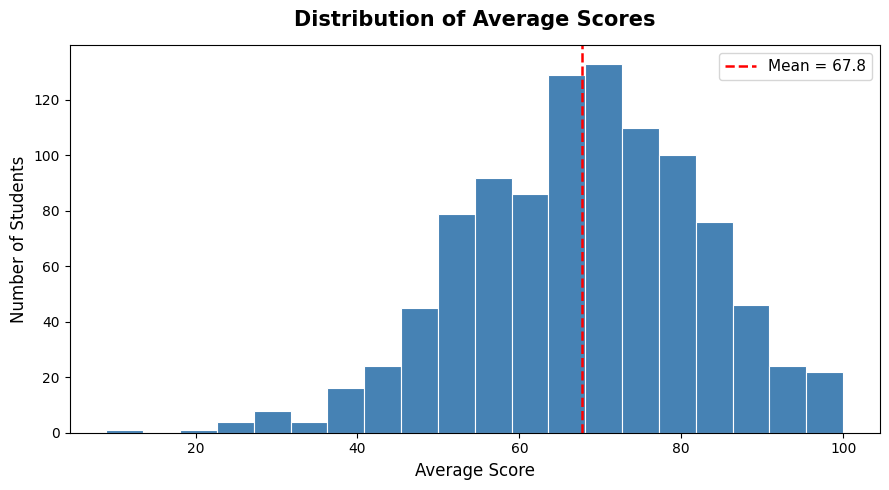

In [20]:
# Chart 1: Score Distribution (Histogram)
# → Shows how scores are spread: are most students clustered around 70? Or spread out?

plt.figure(figsize=(9, 5))
plt.hist(df['average_score'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
plt.axvline(df['average_score'].mean(), color='red', linestyle='--', linewidth=1.8,
            label=f"Mean = {df['average_score'].mean():.1f}")
plt.title('Distribution of Average Scores', fontsize=15, fontweight='bold', pad=14)
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

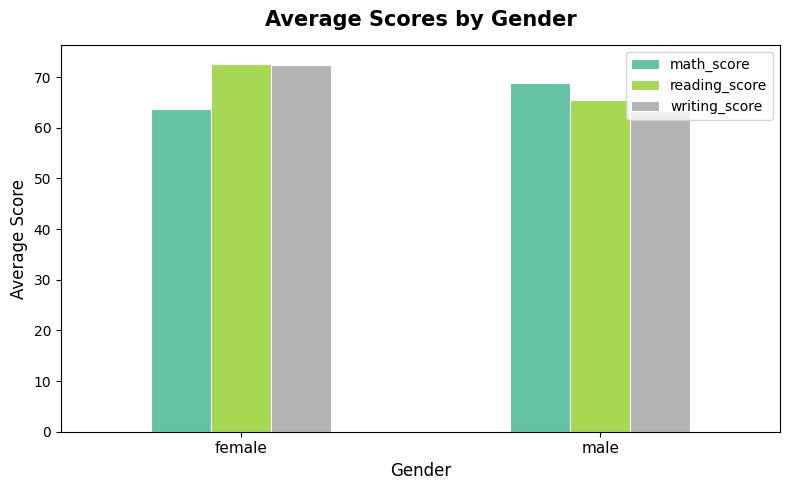

In [21]:
# Chart 2: Average Scores by Gender (Bar Chart)
# → Do male and female students score differently in each subject?

gender_avg = df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean().round(2)

gender_avg.plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='white', linewidth=0.8)
plt.title('Average Scores by Gender', fontsize=15, fontweight='bold', pad=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

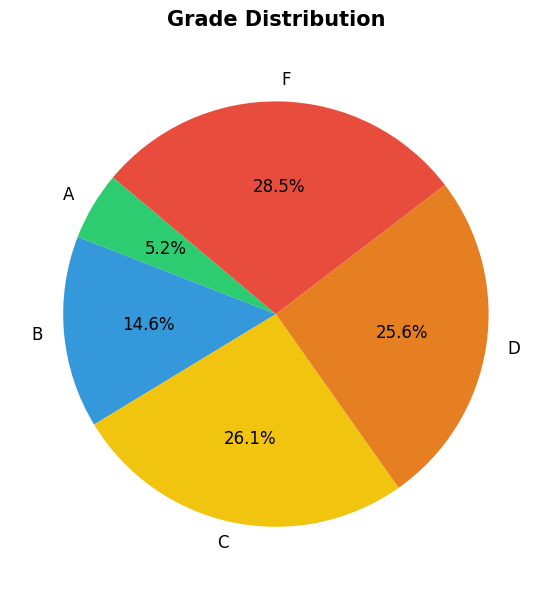

In [22]:
# Chart 3: Grade Distribution (Pie Chart)
# → What percentage of students got each grade?

plt.figure(figsize=(7, 6))
grade_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c'],
    textprops={'fontsize': 12}
)
plt.title('Grade Distribution', fontsize=15, fontweight='bold', pad=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

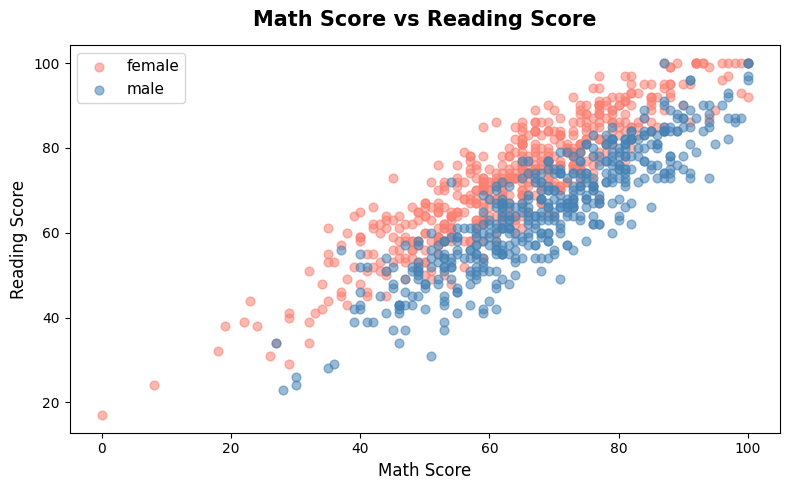

In [23]:
# Chart 4: Math vs Reading Score (Scatter Plot)
# → Is there a relationship between math and reading scores?
#   Each dot is one student, coloured by gender.

plt.figure(figsize=(8, 5))
colors = {'male': 'steelblue', 'female': 'salmon'}
for gender, group in df.groupby('gender'):
    plt.scatter(group['math_score'], group['reading_score'],
                label=gender, alpha=0.55, color=colors[gender], s=40)
plt.title('Math Score vs Reading Score', fontsize=15, fontweight='bold', pad=14)
plt.xlabel('Math Score', fontsize=12)
plt.ylabel('Reading Score', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\j\AppData\Local\Temp\ipykernel_23360\1910309635.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_preparation_course', y='average_score',


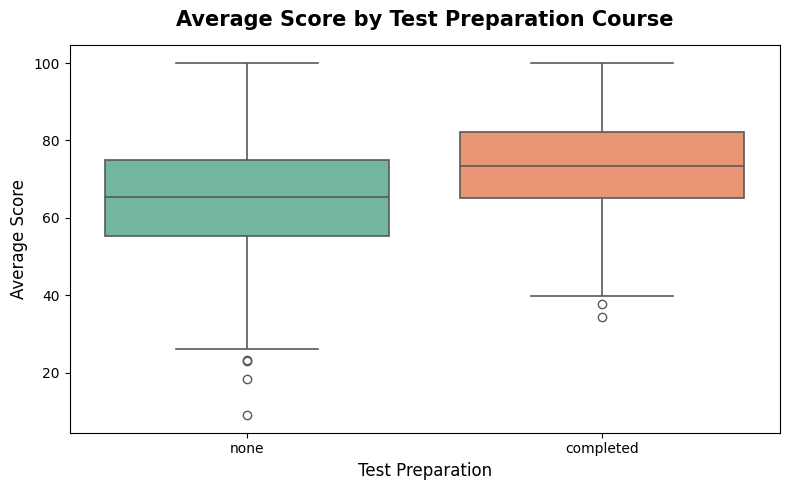

In [24]:
# Chart 5: Effect of Test Preparation (Boxplot)
# → Does completing the test prep course actually improve scores?
#   A boxplot shows us the spread and median for each group.

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='test_preparation_course', y='average_score',
            palette='Set2', linewidth=1.2)
plt.title('Average Score by Test Preparation Course', fontsize=15, fontweight='bold', pad=14)
plt.xlabel('Test Preparation', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.tight_layout()
plt.show()

---
## 💾 Step 13 — Save Our Work

After all our changes (new columns, grades, etc.), let's save the updated DataFrame to a new CSV file so we don't lose our work.

In [25]:
df.to_csv('StudentsPerformance_cleaned.csv', index=False)
# index=False means: don't write the row numbers into the file

print('✅ File saved as: StudentsPerformance_cleaned.csv')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')

✅ File saved as: StudentsPerformance_cleaned.csv
   Shape: 1000 rows × 11 columns


---
## 📝 Summary — What We Covered Today

| Step | Task | Key Function |
|:---:|---|---|
| 1 | Import libraries | `import pandas as pd` |
| 2 | Load CSV | `pd.read_csv()` |
| 3 | Explore data | `.head()` · `.info()` · `.shape` |
| 4 | Statistics | `.describe()` |
| 5 | Missing values | `.isnull().sum()` |
| 6 | Clean column names | `.str.lower().str.replace()` |
| 7 | New columns | `df['col'] = ...` |
| 8 | Apply a function | `.apply(func)` |
| 9 | Filter rows | `df[df['col'] == value]` |
| 10 | Group & aggregate | `.groupby().mean()` |
| 11 | Sort | `.sort_values()` |
| 12 | Charts | `plt` · `sns` |
| 13 | Save | `.to_csv()` |

---

## 🎯 Your Turn — Workshop Challenge

Try to answer these questions using what you just learned:

1. What is the **average math score** for students whose parents have a *bachelor's degree*?
2. Which **parental education level** produces the highest average score overall?
3. How many **female students** received grade A?
4. Create a **bar chart** showing average scores by race/ethnicity group.
5. *(Bonus)* Does the lunch type affect scores? Use `groupby` to find out.

```python
# Your code goes here!



```

> 🚀 **Good luck! If you get stuck, raise your hand and we'll figure it out together.**